In [1]:
# https://datahacker.rs/006-gans-how-to-develop-a-1d-gan-from-scratch/

In [2]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import joblib
import torch.nn.functional as F

## Real data

In [3]:
df_gan_real = joblib.load('../inputs/pre-processed/df_gan_real.pkl')
df_gan_real

,P_Z0_before,P_Z0_after,P_Z1_before,P_Z1_after,P_WH_before,P_WH_after,T_Z0_before,T_Z0_after,T_Z1_before,T_Z1_after,P_bottom_before,P_bottom_after,T_WH_before,T_WH_after,failure
0,0.880689,0.883310,0.880682,0.885696,0.911670,0.911528,0.000000,0.286272,0.300062,0.300035,0.681089,0.679748,0.900163,0.895531,0.0
1,0.881517,0.884084,0.881510,0.886472,0.912527,0.912327,0.286213,0.286228,0.299981,0.300048,0.681729,0.680344,0.900614,0.895979,0.0
2,0.880936,0.883653,0.880929,0.886040,0.911926,0.911882,0.286257,0.286242,0.300075,0.300075,0.681280,0.680012,0.900163,0.895979,0.0
3,0.963877,0.967061,0.963869,0.969673,0.997784,0.997954,0.273708,0.273602,0.285997,0.285829,0.745423,0.744198,0.216735,0.216961,0.0
4,0.882956,0.885347,0.882949,0.887738,0.914017,0.913630,0.286184,0.286199,0.299955,0.299968,0.682842,0.681316,0.901065,0.896428,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,0.883036,0.895666,0.870898,0.887070,0.287619,0.277391,0.286052,0.290235,0.301354,0.294628,0.912764,0.918396,0.887348,0.889282,1.0
9995,0.884062,0.878863,0.858351,0.873352,0.354632,0.346057,0.286374,0.280552,0.298908,0.299375,0.912205,0.858235,0.851455,0.793433,1.0
9996,0.918889,0.897820,0.921813,0.923951,0.355926,0.349120,0.286013,0.283202,0.298104,0.305716,0.888643,0.930148,0.829160,0.875546,1.0
9997,0.883785,0.883423,0.892194,0.882118,0.348669,0.353311,0.291266,0.283867,0.303656,0.303889,0.920046,0.913415,0.877215,0.855864,1.0


In [4]:
df_gan_real.describe()

,P_Z0_before,P_Z0_after,P_Z1_before,P_Z1_after,P_WH_before,P_WH_after,T_Z0_before,T_Z0_after,T_Z1_before,T_Z1_after,P_bottom_before,P_bottom_after,T_WH_before,T_WH_after,failure
count,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000,9952.000000
mean,0.885386,0.888107,0.885516,0.890417,0.621929,0.621826,0.282035,0.282245,0.295613,0.295404,0.788410,0.789576,0.824172,0.819970,0.497588
std,0.106734,0.109333,0.106761,0.109445,0.305231,0.305790,0.032427,0.031461,0.032096,0.034295,0.139919,0.142756,0.186260,0.186731,0.500019
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.878326,0.881000,0.878313,0.883193,0.349702,0.349725,0.282908,0.282869,0.296197,0.296473,0.682305,0.680970,0.849536,0.848136,0.000000
50%,0.883861,0.886560,0.883887,0.888841,0.657162,0.656717,0.286199,0.286199,0.299888,0.299900,0.746957,0.745605,0.897005,0.892840,0.000000
75%,0.910181,0.916668,0.910383,0.919934,0.913525,0.913426,0.287518,0.287532,0.300275,0.300302,0.914168,0.914058,0.901065,0.896876,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
real_data_tensor = torch.tensor(df_gan_real.values)

In [6]:
real_data_tensor

tensor([[0.8807, 0.8833, 0.8807,  ..., 0.9002, 0.8955, 0.0000],
        [0.8815, 0.8841, 0.8815,  ..., 0.9006, 0.8960, 0.0000],
        [0.8809, 0.8837, 0.8809,  ..., 0.9002, 0.8960, 0.0000],
        ...,
        [0.9189, 0.8978, 0.9218,  ..., 0.8292, 0.8755, 1.0000],
        [0.8838, 0.8834, 0.8922,  ..., 0.8772, 0.8559, 1.0000],
        [0.9785, 0.9743, 0.9552,  ..., 0.9416, 0.9185, 1.0000]],
       dtype=torch.float64)

In [7]:
real_data_tensor.shape

torch.Size([9952, 15])

In [8]:
len(real_data_tensor)

9952

In [9]:
real_data_tensor[torch.randint(0, len(real_data_tensor), (4, )) , :]

tensor([[0.9639, 0.9670, 0.9639, 0.9696, 0.9978, 0.9979, 0.2737, 0.2736, 0.2860,
         0.2859, 0.7454, 0.7442, 0.2167, 0.2165, 0.0000],
        [0.8846, 0.8872, 0.8846, 0.8896, 0.9158, 0.9155, 0.2862, 0.2862, 0.2998,
         0.2999, 0.6841, 0.6827, 0.9015, 0.8973, 0.0000],
        [0.8829, 0.8852, 0.8829, 0.8876, 0.9140, 0.9135, 0.2862, 0.2862, 0.3000,
         0.3000, 0.6828, 0.6812, 0.9011, 0.8964, 0.0000],
        [0.9659, 0.9689, 0.9659, 0.9715, 0.9998, 0.9998, 0.2770, 0.2770, 0.2907,
         0.2907, 0.7470, 0.7456, 0.2163, 0.2165, 0.0000]], dtype=torch.float64)

In [10]:
def generate_data_samples(n=100):
    
    sample = real_data_tensor[torch.randint(0, len(real_data_tensor), (n, )) , :]
    sample = sample.float()
    
    y_data = torch.ones((n,1))

    return sample, y_data

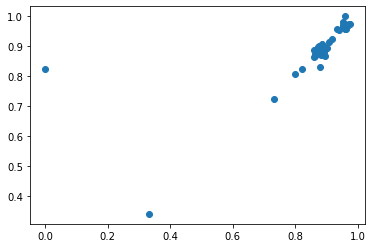

In [11]:
test_generated_data = generate_data_samples(100)

plt.scatter(test_generated_data[0][:,0].numpy(), test_generated_data[0][:,1].numpy())

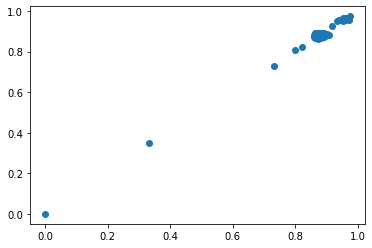

In [12]:
plt.scatter(test_generated_data[0][:,0].numpy(), test_generated_data[0][:,2].numpy())

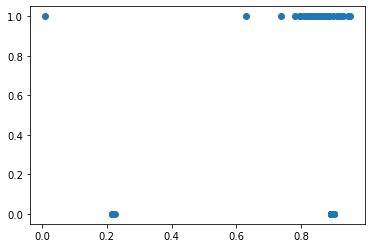

In [13]:
plt.scatter(test_generated_data[0][:,13].numpy(), test_generated_data[0][:,14].numpy())

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(15, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 1)

    def forward(self,x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = torch.sigmoid(x)
        return x

In [15]:
discriminator = Discriminator()
# test a discriminator with a simple input - sanity check
x_data_test = torch.rand(15)
discriminator(x_data_test)

tensor([0.4692], grad_fn=<SigmoidBackward0>)

In [16]:
torch.rand((5, 15))

tensor([[0.8682, 0.5991, 0.6297, 0.9605, 0.9721, 0.4875, 0.4399, 0.5069, 0.6169,
         0.9341, 0.6572, 0.7172, 0.9424, 0.4369, 0.6331],
        [0.0504, 0.3677, 0.6541, 0.5000, 0.5102, 0.9537, 0.8425, 0.2625, 0.1555,
         0.1865, 0.3277, 0.4981, 0.0320, 0.8925, 0.2220],
        [0.3163, 0.1714, 0.0457, 0.2456, 0.5606, 0.4224, 0.5796, 0.2220, 0.1946,
         0.1706, 0.4199, 0.5718, 0.5034, 0.2936, 0.9305],
        [0.2346, 0.9078, 0.0355, 0.9023, 0.9141, 0.5490, 0.4509, 0.7246, 0.6322,
         0.4688, 0.0739, 0.8711, 0.3265, 0.3183, 0.7059],
        [0.7103, 0.3295, 0.9693, 0.6058, 0.1352, 0.9662, 0.7404, 0.2997, 0.9553,
         0.3508, 0.2448, 0.8557, 0.5386, 0.2510, 0.1008]])

In [17]:
generate_data_samples(1)[0].shape

torch.Size([1, 15])

In [18]:
def generate_dummy_fake_data(n):
    
    x_random = torch.rand((n, 15))
    
    y_fake = torch.zeros((n,1))
    
    return x_random, y_fake

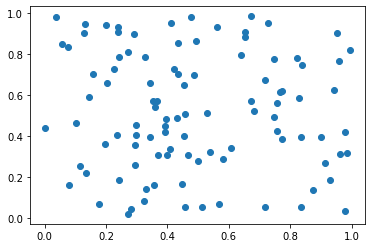

In [19]:
x_fake,y_fake = generate_dummy_fake_data(100)
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 1].numpy())

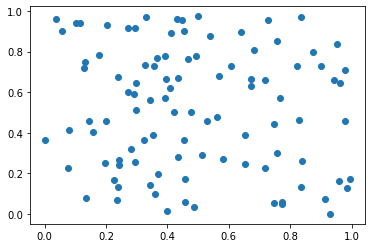

In [20]:
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 2].numpy())

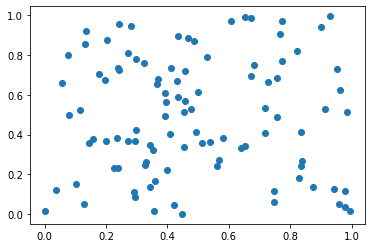

In [21]:
plt.scatter(x_fake[:, 0].numpy(),x_fake[:, 3].numpy())

In [22]:
discriminator = Discriminator()
optimizer = torch.optim.Adam(discriminator.parameters(), lr = 0.001) 
criterion = torch.nn.BCELoss()

In [23]:
epochs = 1000
n = 100
x_data, y_data = generate_data_samples(n)
x_fake, y_fake = generate_dummy_fake_data(n)

x_all = torch.vstack((x_data, x_fake))
y_all = torch.vstack((y_data, y_fake))
all_loss = []
for i in range(epochs):
    y_hat = discriminator(x_all)
    loss = criterion(y_hat, y_all)
    all_loss.append(loss.item())

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

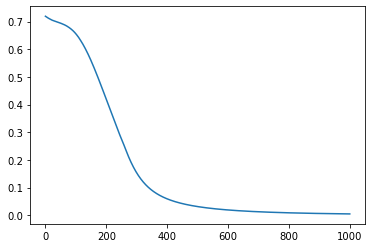

In [24]:
plt.plot(all_loss)

In [25]:
# define a Generator Model

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.fc1 = nn.Linear(5, 50)
        self.fc2 = nn.Linear(50, 25)
        self.fc3 = nn.Linear(25, 15)
        

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = F.sigmoid(x)
        return x

In [26]:
generator = Generator()
test_generator = generator(torch.rand(5))
print(test_generator)

tensor([0.4786, 0.4587, 0.5464, 0.5491, 0.4817, 0.4734, 0.5309, 0.4879, 0.4812,
        0.4418, 0.5079, 0.5017, 0.5266, 0.5198, 0.4965],
       grad_fn=<SigmoidBackward0>)


In [27]:
def generate_latent_points(n, latent_dim=5):
    # here we will assume that in the z-space 
    # or latent space we have 5 dimensional random vector 
    z = torch.rand(n*latent_dim)
    return z.view((n,latent_dim))

a = generate_latent_points(10)
print(a)

tensor([[0.7319, 0.6635, 0.1485, 0.2048, 0.7720],
        [0.8855, 0.4241, 0.1457, 0.7967, 0.5887],
        [0.3505, 0.4725, 0.8559, 0.4399, 0.8035],
        [0.4461, 0.0038, 0.6835, 0.7147, 0.5015],
        [0.8777, 0.3263, 0.4145, 0.8908, 0.8004],
        [0.4360, 0.5808, 0.8289, 0.9831, 0.8527],
        [0.3757, 0.1344, 0.1886, 0.6701, 0.1335],
        [0.3848, 0.9164, 0.9362, 0.1037, 0.7911],
        [0.9136, 0.4206, 0.8438, 0.5371, 0.5369],
        [0.7899, 0.5010, 0.4998, 0.2880, 0.8303]])


In [28]:
def generate_fake_samples(generator, n, latent_dim=5):
    z = generate_latent_points(n)
    fake_data = generator(z)
    return fake_data 

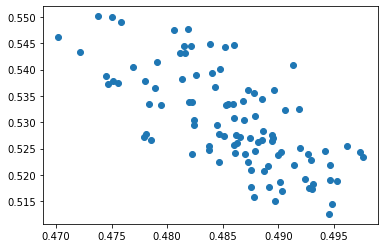

In [29]:
fake_data_test = generate_fake_samples(generator, 100)
plt.scatter(fake_data_test[:,0].detach().numpy(), fake_data_test[:,2].detach().numpy())

In [30]:
training_steps = 50_000

# Models
generator =     Generator()
discriminator = Discriminator()

# Optimizers
generator_optimizer     = torch.optim.Adam(generator.parameters(),     lr=0.001)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.001)

# loss
loss = nn.BCELoss()

discriminator_losses = []
generator_losses = []

N = 128

for i in tqdm(range(training_steps)):
    # zero the gradients on each iteration
    generator_optimizer.zero_grad()
#    if i%5000 ==0:
#        print(f"{i} \n")

    # Create a fake data with a generator
    fake_data = generate_fake_samples(generator, N)

    # here we define the INVERSE labels for fake data
    fake_data_label = torch.ones(N,1)

    # Generate examples of real data
    real_data, real_data_label = generate_data_samples(N)
    
    # Train the generator
    # We invert the labels here and don't train the discriminator because we want the generator
    # to make things the discriminator classifies as true.
    generator_discriminator_out = discriminator(fake_data)
    generator_loss = loss(generator_discriminator_out, fake_data_label)
    generator_loss.backward()
    generator_optimizer.step()
    generator_losses.append(generator_loss.item())

    # Train the discriminator on the true/generated data
    discriminator_optimizer.zero_grad()
    true_discriminator_out = discriminator(real_data)
    true_discriminator_loss = loss(true_discriminator_out, real_data_label)

    # here a fake_data is passed with a gradient turned off
    # see our post about <a href="https://datahacker.rs/004-computational-graph-and-autograd-with-pytorch/#Automatic-differentiation-module-in-PyTorch---Autograd">AUTOGRAD</a>
    generator_discriminator_out = discriminator(fake_data.detach())
    generator_discriminator_loss = loss(generator_discriminator_out, torch.zeros(N,1))
    discriminator_loss = (true_discriminator_loss + generator_discriminator_loss) / 2
    discriminator_loss.backward()
    discriminator_optimizer.step()
    discriminator_losses.append(discriminator_loss.item())

100%|████████████████████████████████████| 50000/50000 [02:23<00:00, 349.31it/s]


In [31]:
real_data

tensor([[0.8837, 0.8862, 0.8837,  ..., 0.9006, 0.8969, 0.0000],
        [0.9726, 0.9644, 0.9658,  ..., 0.8966, 0.8397, 1.0000],
        [0.9346, 0.9483, 0.9285,  ..., 0.8724, 0.8922, 1.0000],
        ...,
        [0.8781, 0.8806, 0.8781,  ..., 0.8970, 0.8933, 0.0000],
        [0.8737, 0.8860, 0.8742,  ..., 0.8827, 0.8572, 1.0000],
        [0.8810, 0.8836, 0.8810,  ..., 0.9006, 0.8964, 0.0000]])

In [32]:
fake_data

tensor([[9.9812e-01, 9.2427e-01, 2.3081e-02,  ..., 9.9998e-01, 1.1087e-03,
         1.2948e-04],
        [9.9949e-01, 7.7720e-01, 2.0123e-01,  ..., 9.9986e-01, 4.9440e-03,
         1.2287e-03],
        [9.9975e-01, 8.3337e-01, 6.7728e-02,  ..., 9.9998e-01, 9.7754e-04,
         1.7038e-04],
        ...,
        [9.9927e-01, 8.8639e-01, 3.8219e-02,  ..., 9.9997e-01, 1.4810e-03,
         2.1211e-04],
        [9.9902e-01, 8.2873e-01, 1.2536e-01,  ..., 9.9989e-01, 5.0405e-03,
         8.2025e-04],
        [9.9216e-01, 8.0405e-01, 2.5521e-01,  ..., 9.9741e-01, 4.8218e-02,
         1.1791e-02]], grad_fn=<SigmoidBackward0>)

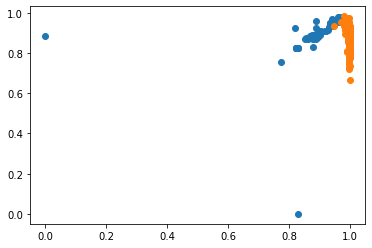

In [33]:
plt.scatter(real_data[:,0].detach().numpy(), real_data[:,1].detach().numpy())
plt.scatter(fake_data[:,0].detach().numpy(), fake_data[:,1].detach().numpy())

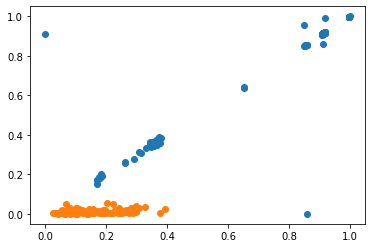

In [34]:
plt.scatter(real_data[:,4].detach().numpy(), real_data[:,5].detach().numpy())
plt.scatter(fake_data[:,4].detach().numpy(), fake_data[:,5].detach().numpy())

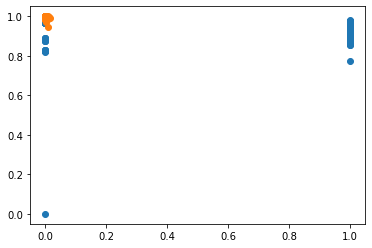

In [35]:
plt.scatter(real_data[:,14].detach().numpy(), real_data[:,0].detach().numpy())
plt.scatter(fake_data[:,14].detach().numpy(), fake_data[:,0].detach().numpy())

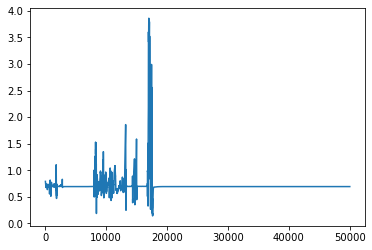

In [36]:
plt.plot(generator_losses)

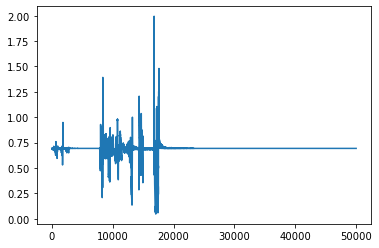

In [37]:
plt.plot(discriminator_losses)

In [38]:
fake_data[:, 14]

tensor([1.2948e-04, 1.2287e-03, 1.7038e-04, 2.6996e-03, 1.7306e-03, 4.5086e-04,
        1.5871e-05, 1.6492e-04, 2.2129e-05, 3.3917e-04, 2.3721e-03, 1.6794e-04,
        9.1813e-04, 1.7135e-04, 1.5342e-04, 2.2422e-04, 2.9185e-03, 6.2268e-04,
        2.6816e-04, 8.3706e-04, 1.0460e-04, 3.1803e-04, 1.4360e-03, 4.3965e-04,
        1.8514e-03, 1.8146e-03, 3.4390e-04, 1.7054e-05, 3.4092e-03, 4.0896e-04,
        1.8273e-04, 1.7200e-05, 6.8622e-04, 1.2638e-03, 6.1920e-04, 3.1328e-05,
        3.5955e-03, 1.0947e-03, 4.2933e-03, 5.1568e-04, 1.3414e-03, 5.0211e-05,
        8.2178e-03, 4.6387e-04, 3.3562e-04, 1.5658e-02, 1.2252e-04, 4.3237e-05,
        1.9629e-03, 5.1388e-04, 1.0777e-04, 1.0266e-03, 3.0276e-03, 6.9202e-03,
        5.7081e-05, 1.2535e-03, 1.0710e-02, 9.0744e-05, 5.8228e-04, 1.3372e-03,
        4.4851e-03, 3.2626e-04, 7.1244e-05, 8.3605e-03, 1.8277e-03, 6.9452e-03,
        1.1716e-03, 1.7989e-04, 9.3840e-04, 1.8481e-03, 8.8200e-04, 8.7402e-05,
        1.9328e-03, 5.3184e-04, 4.8414e-

In [39]:
real_data[:, 14]

tensor([0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
        1., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0.,
        0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
        1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 1., 0.,
        1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
        0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0.,
        1., 0.])